In [186]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import time
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

In [187]:
path = r'/Users/artoe/Documents/DataAnalytics/Machine Learning With Python/Achievement 2/data'

In [188]:
#import cleaned, unscaled weather data
weather = pd.read_csv(os.path.join(path, 'weather_cleaned.csv'), index_col = False)

In [189]:
#import pleasant weather data
pleasant = pd.read_csv(os.path.join(path, 'Pleasant_Weather.csv'), index_col = False)

In [190]:
weather.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max,KASSEL_cloud_cover,MUNCHENB_pressure,STOCKHOLM_humidity
0,19600101,1,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,...,1.0003,0.45,0.34,4.7,8.5,6.0,10.9,8,1.0304,0.98
1,19600102,1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,...,1.0007,0.25,0.84,0.7,8.9,5.6,12.1,8,1.0292,0.62
2,19600103,1,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,...,1.0096,0.17,0.08,0.1,10.5,8.1,12.9,7,1.0320,0.69
3,19600104,1,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,...,1.0184,0.13,0.98,0.0,7.4,7.3,10.6,8,1.0443,0.98
4,19600105,1,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,...,1.0328,0.46,0.00,5.7,5.7,3.0,8.4,7,1.0430,0.96


In [191]:
pleasant.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [192]:
#extracting weather data from 2010-2020
weather2010 = weather[weather['DATE'].astype(str).str.startswith('201')] 

In [193]:
#check range
print('start date:', weather2010['DATE'].head(1))
print('end date:', weather2010['DATE'].tail(1))

start date: 18263    20100101
Name: DATE, dtype: int64
end date: 21914    20191231
Name: DATE, dtype: int64


In [194]:
#extracting pleasant weather data from 2010-2020
pleasant2010 = pleasant[pleasant['DATE'].astype(str).str.startswith('201')] 

In [195]:
#check range
print('start date:', pleasant2010['DATE'].head(1))
print('end date:', pleasant2010['DATE'].tail(1))

start date: 18263    20100101
Name: DATE, dtype: int64
end date: 21914    20191231
Name: DATE, dtype: int64


In [196]:
#drop date and month columns
weather2010.drop(['DATE', 'MONTH'], axis=1, inplace=True)

In [197]:
pleasant2010.drop(['DATE'], axis=1, inplace=True)

In [198]:
weather2010.head()

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,...,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max,KASSEL_cloud_cover,MUNCHENB_pressure,STOCKHOLM_humidity
18263,8,0.93,0.9965,0.18,0.56,0.0,2.9,-0.2,4.8,6,...,1.0121,0.43,0.00,6.0,1.7,-1.6,5.0,8,1.0054,0.76
18264,3,0.74,1.0193,0.58,0.00,5.2,-1.5,-4.2,0.4,8,...,1.0196,0.45,0.00,6.0,0.8,-4.5,6.2,7,1.0250,0.74
18265,3,0.75,1.0226,0.61,0.00,6.3,-3.2,-6.0,1.1,7,...,1.0196,0.36,0.41,1.6,0.5,-4.1,5.1,8,1.0404,0.84
18266,5,0.83,1.0169,0.48,0.00,3.7,-4.9,-8.3,-3.1,2,...,1.0219,0.48,0.51,6.5,3.7,1.3,3.8,7,1.0316,0.89
18267,7,0.78,1.0073,0.53,0.04,4.4,-4.0,-7.1,-1.5,6,...,1.0117,0.45,0.09,4.7,2.3,-0.7,5.4,7,1.0206,0.78


In [199]:
pleasant2010.head()

,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
18263,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18264,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18265,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18266,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18267,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [200]:
weather2010.shape

(3652, 135)

In [201]:
pleasant2010.shape

(3652, 15)

#### Convert data to appropriate format for classification

In [203]:
#identify X and y
X = weather2010
y = pleasant2010

In [204]:
y.shape

(3652, 15)

In [205]:
y

,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
18263,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18264,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18265,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18266,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18267,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21910,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21911,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21912,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21913,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [206]:
#we need to reshape y into a single value representation
y = pleasant2010.sum(axis=1)

In [207]:
y.head(30)

18263    0
18264    0
18265    0
18266    0
18267    0
18268    0
18269    0
18270    0
18271    0
18272    0
18273    0
18274    0
18275    0
18276    0
18277    0
18278    0
18279    0
18280    0
18281    0
18282    0
18283    0
18284    0
18285    0
18286    0
18287    0
18288    0
18289    0
18290    0
18291    0
18292    0
dtype: int64

In [208]:
print('y shape', y.shape)
print('y unique values', y.unique())

y shape (3652,)
y unique values [ 0  1  3  2  5  4  6  9  7 10  8 11 12 13]


In [209]:
#the unique values are the number of pleasant weather reports on that day. we will define this as a list to apply as a class later
pleasantdays = ['0','1','2','3','4','5','6','7','8','9','10','11','12','13']

In [210]:
#convert X to array
X = np.array(X)

In [211]:
#check shape once more
print('X shape', X.shape)
print('y shape', y.shape)

X shape (3652, 135)
y shape (3652,)


In [212]:
#split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42)

In [213]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(2739, 135) (2739,)
(913, 135) (913,)


#### Grid Search

In [215]:
clf = RandomForestClassifier()

In [216]:
# Grid search cv
grid_space={'max_depth':[5,10,15],
              'n_estimators':[50,100,200],
              'max_features':[11,13,15,17],
              'min_samples_leaf':[1,2,3],
              'min_samples_split':[1,2,3]
           }

In [217]:
start = time.time()
grid = GridSearchCV(clf,param_grid=grid_space,cv=3,scoring='accuracy', verbose=3, n_jobs=-1)
model_grid = grid.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Search took 3.7446340282758075 minutes


In [218]:
# grid search results
print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))

Best GRID search hyperparameters are: {'max_depth': 15, 'max_features': 17, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best GRID search score is: 0.5764877692588536


#### Random Search

In [220]:
# Random search cv
rs_space={'max_depth':list(np.arange(10, 200, step=20)) + [None],
              'n_estimators':np.arange(10, 500, step=50),
              'max_features':randint(1,20),
              'criterion':['gini','entropy'],
              'min_samples_leaf':randint(1,4),
              'min_samples_split':np.arange(2, 10, step=2)
         }

In [221]:
# creating a RF classifier
clf2= RandomForestClassifier()

In [222]:
start = time.time()
rf_random = RandomizedSearchCV(clf2, rs_space, n_iter=200, scoring='accuracy', verbose=3, n_jobs=-1, cv=3) 
model_random = rf_random.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 200 candidates, totalling 600 fits
Search took 9.449624550342559 minutes


In [223]:
# random search results
print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best RANDOM search hyperparameters are: {'criterion': 'entropy', 'max_depth': 170, 'max_features': 16, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 460}
Best RANDOM search score is: 0.583424607520993


#### Best Score and Hyperparameters for Grid and Random Searches

In [225]:
# grid search results
print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))
# random random search results
print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best GRID search hyperparameters are: {'max_depth': 15, 'max_features': 17, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best GRID search score is: 0.5764877692588536
Best RANDOM search hyperparameters are: {'criterion': 'entropy', 'max_depth': 170, 'max_features': 16, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 460}
Best RANDOM search score is: 0.583424607520993


### Random Forest Classifier with Best Hyperparameters According to Grid Search

In [227]:
# creating a RF classifier
clf3 = RandomForestClassifier(n_estimators=200, max_depth=15, max_features=17, min_samples_leaf=3, min_samples_split=2) 

In [228]:
#training model on the train dataset
clf3.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, max_features=17, min_samples_leaf=3,
                       n_estimators=200)

In [229]:
# performing predictions on the test dataset
y_pred = clf3.predict(X_test)
  
# using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  0.5684556407447974


[Text(0.26335093896713613, 0.96875, 'x[86] <= 12.15\ngini = 0.838\nsamples = 1733\nvalue = [960.0, 262.0, 175.0, 169.0, 157.0, 171.0, 182.0, 136.0\n139.0, 125.0, 127.0, 94.0, 36.0, 6.0]\nclass = 0'),
 Text(0.04508998435054773, 0.90625, 'x[17] <= 17.95\ngini = 0.27\nsamples = 679\nvalue = [909, 64, 35, 15, 9, 17, 5, 3, 9, 1, 1, 0, 0\n0]\nclass = 0'),
 Text(0.15422046165884193, 0.9375, 'True  '),
 Text(0.0297339593114241, 0.84375, 'x[111] <= 12.35\ngini = 0.067\nsamples = 568\nvalue = [871, 19, 5, 2, 0, 3, 0, 0, 2, 0, 0, 0, 0, 0]\nclass = 0'),
 Text(0.026604068857589983, 0.78125, 'x[8] <= 17.3\ngini = 0.055\nsamples = 564\nvalue = [871, 17, 5, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]\nclass = 0'),
 Text(0.023474178403755867, 0.71875, 'x[79] <= 17.55\ngini = 0.04\nsamples = 559\nvalue = [868.0, 15.0, 3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0\n0.0, 0.0, 0.0, 0.0]\nclass = 0'),
 Text(0.02034428794992175, 0.65625, 'x[8] <= 9.65\ngini = 0.029\nsamples = 555\nvalue = [866, 12, 1, 0, 0, 0, 0, 0, 0, 0, 0, 

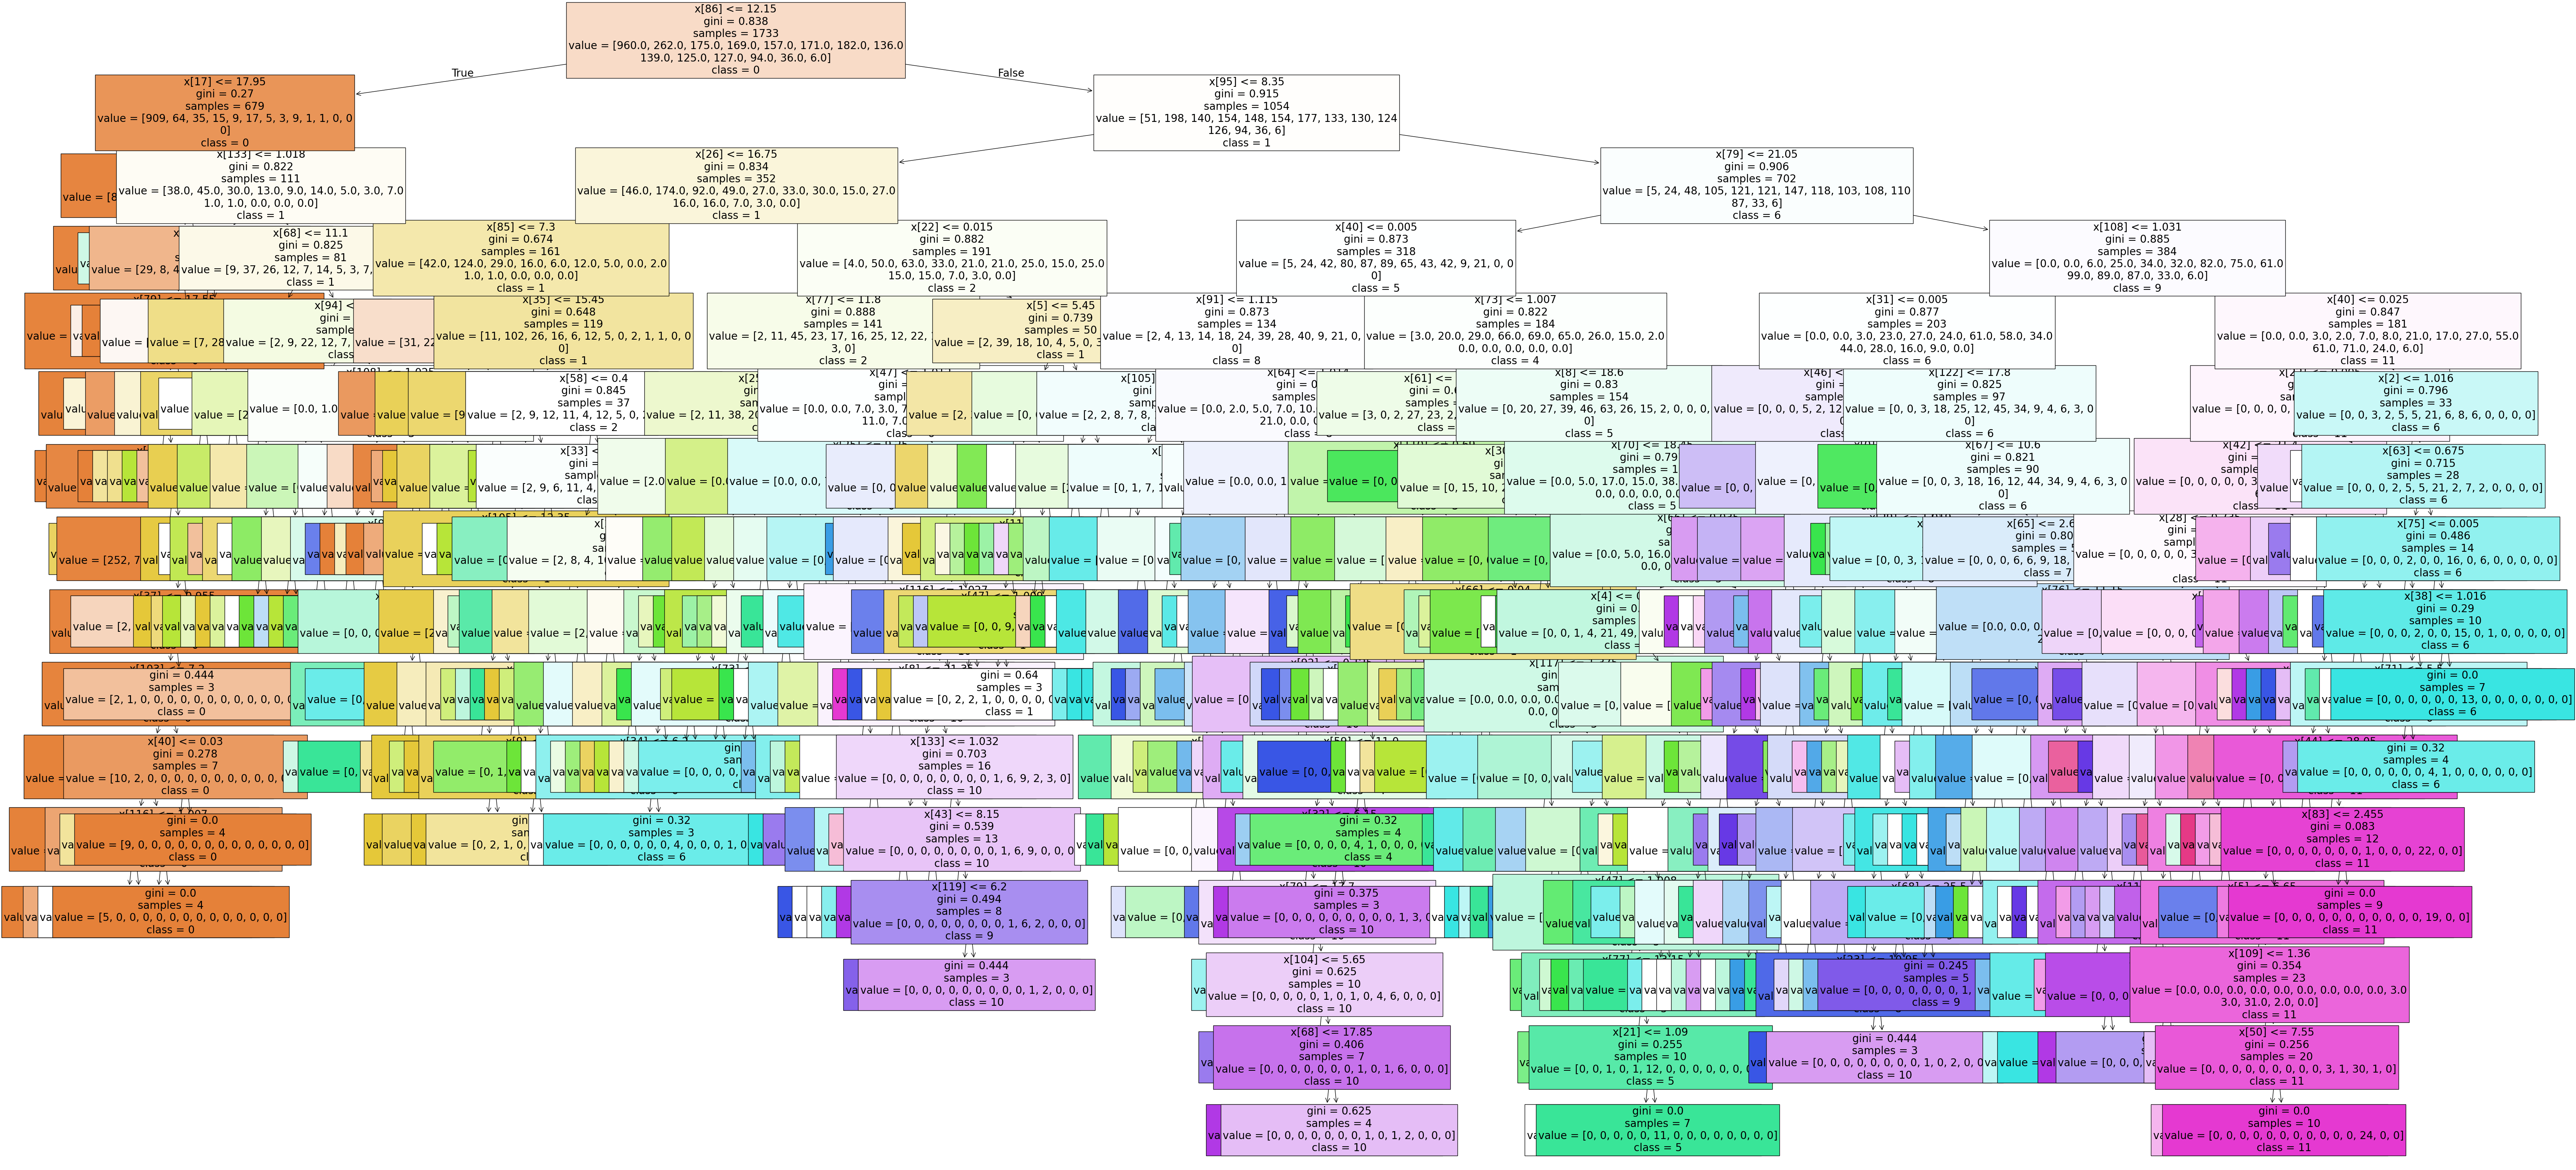

In [230]:
fig = plt.figure(figsize=(80,40))
plot_tree(clf3.estimators_[15], fontsize = 20, class_names=pleasantdays, filled=True)

#### this model is 56.8% accurate

In [232]:
fig.savefig(f"{path}/2.4_forest_grid.png")

### Feature Importances with Best Hyperparameters according to Grid Search

##### Weather Conditions

In [235]:
newarray = clf3.feature_importances_
print(clf3.feature_importances_.shape)
newarray

(135,)


array([3.61503856e-03, 5.04398907e-03, 4.75383065e-03, 5.98755656e-03,
       7.82102490e-03, 9.14188856e-03, 2.57878194e-02, 3.75667105e-03,
       2.45353357e-02, 3.46885839e-03, 4.60299981e-03, 6.40216417e-03,
       3.77040858e-03, 3.98903735e-03, 4.80813661e-03, 9.45998368e-03,
       5.56127507e-03, 1.29575988e-02, 1.20301921e-04, 0.00000000e+00,
       0.00000000e+00, 1.30480208e-03, 3.82620451e-03, 1.15890532e-03,
       3.65930410e-02, 7.07079030e-03, 2.75684460e-02, 2.99259513e-03,
       3.74722665e-03, 6.65121408e-03, 5.11347457e-03, 7.13467372e-03,
       5.22149452e-03, 7.42895739e-03, 4.53699375e-03, 2.23107690e-02,
       1.83230329e-03, 3.93804098e-03, 5.16546215e-03, 4.85797505e-03,
       8.32338320e-03, 5.20063188e-03, 1.24757672e-02, 4.47205351e-03,
       2.88692638e-02, 3.15078121e-03, 5.14725136e-03, 5.11558291e-03,
       6.50613431e-03, 3.02568406e-03, 5.44618325e-03, 9.69578140e-03,
       4.46784777e-03, 1.39566817e-02, 1.63272119e-03, 2.16306694e-03,
      

In [236]:
#reshape feature importance array to show 15 stations, 9 features each
newarray = newarray.reshape(-1,15,9)
print(newarray.shape)
newarray

(1, 15, 9)


array([[[3.61503856e-03, 5.04398907e-03, 4.75383065e-03, 5.98755656e-03,
         7.82102490e-03, 9.14188856e-03, 2.57878194e-02, 3.75667105e-03,
         2.45353357e-02],
        [3.46885839e-03, 4.60299981e-03, 6.40216417e-03, 3.77040858e-03,
         3.98903735e-03, 4.80813661e-03, 9.45998368e-03, 5.56127507e-03,
         1.29575988e-02],
        [1.20301921e-04, 0.00000000e+00, 0.00000000e+00, 1.30480208e-03,
         3.82620451e-03, 1.15890532e-03, 3.65930410e-02, 7.07079030e-03,
         2.75684460e-02],
        [2.99259513e-03, 3.74722665e-03, 6.65121408e-03, 5.11347457e-03,
         7.13467372e-03, 5.22149452e-03, 7.42895739e-03, 4.53699375e-03,
         2.23107690e-02],
        [1.83230329e-03, 3.93804098e-03, 5.16546215e-03, 4.85797505e-03,
         8.32338320e-03, 5.20063188e-03, 1.24757672e-02, 4.47205351e-03,
         2.88692638e-02],
        [3.15078121e-03, 5.14725136e-03, 5.11558291e-03, 6.50613431e-03,
         3.02568406e-03, 5.44618325e-03, 9.69578140e-03, 4.46784777

In [237]:
#sum values for each feature
sumarray = np.sum(newarray[0], axis=0)
sumarray

array([0.06207428, 0.06017632, 0.07123527, 0.07082673, 0.09343396,
       0.15433698, 0.15459363, 0.1735273 , 0.15979553])

In [238]:
#create weather condition labels
weatherconditions = {'CLOUD COVER', 'HUMIDITY', 'PRESSURE', 'GLOBAL RADIATION', 'PRECIPITATION', 'SUNSHINE', 'MEAN TEMP', 'MIN TEMP', 'MAX TEMP'}

In [239]:
#convert array into series
important = pd.Series(sumarray, index = weatherconditions)
important

SUNSHINE            0.062074
MEAN TEMP           0.060176
PRESSURE            0.071235
GLOBAL RADIATION    0.070827
HUMIDITY            0.093434
MAX TEMP            0.154337
CLOUD COVER         0.154594
PRECIPITATION       0.173527
MIN TEMP            0.159796
dtype: float64

In [240]:
#create a dataframe for plotting these features
df_important = pd.DataFrame({
    'Weather Condition': important.index,
    'Importance': important.values
})
df_important.head

<bound method NDFrame.head of   Weather Condition  Importance
0          SUNSHINE    0.062074
1         MEAN TEMP    0.060176
2          PRESSURE    0.071235
3  GLOBAL RADIATION    0.070827
4          HUMIDITY    0.093434
5          MAX TEMP    0.154337
6       CLOUD COVER    0.154594
7     PRECIPITATION    0.173527
8          MIN TEMP    0.159796>

In [241]:
#sort values of df_important for plot clarity
df_important = df_important.sort_values(by='Importance',ascending = False)

{'SUNSHINE', 'MEAN TEMP', 'PRESSURE', 'GLOBAL RADIATION', 'HUMIDITY', 'MAX TEMP', 'CLOUD COVER', 'PRECIPITATION', 'MIN TEMP'}


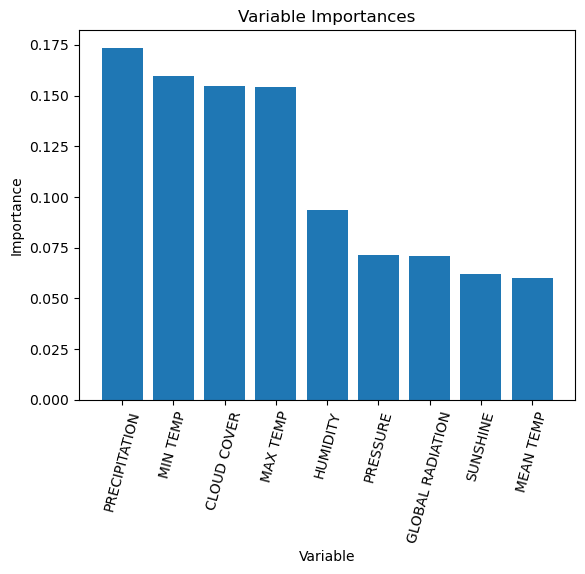

In [242]:
#plot features by importance
print(weatherconditions)
plt.bar(df_important['Weather Condition'], df_important['Importance'], orientation = 'vertical')
plt.xticks(rotation=75, fontsize=10, ha='center')
plt.ylabel('Importance'); plt.xlabel('Variable'); plt.title('Variable Importances');
plt.show()

##### Precipitation, Minimum Temperature and Cloud Cover are the most important features for classification here.

##### Weather Stations

In [245]:
newarray2 = clf3.feature_importances_
print(clf3.feature_importances_.shape)
newarray2

(135,)


array([3.61503856e-03, 5.04398907e-03, 4.75383065e-03, 5.98755656e-03,
       7.82102490e-03, 9.14188856e-03, 2.57878194e-02, 3.75667105e-03,
       2.45353357e-02, 3.46885839e-03, 4.60299981e-03, 6.40216417e-03,
       3.77040858e-03, 3.98903735e-03, 4.80813661e-03, 9.45998368e-03,
       5.56127507e-03, 1.29575988e-02, 1.20301921e-04, 0.00000000e+00,
       0.00000000e+00, 1.30480208e-03, 3.82620451e-03, 1.15890532e-03,
       3.65930410e-02, 7.07079030e-03, 2.75684460e-02, 2.99259513e-03,
       3.74722665e-03, 6.65121408e-03, 5.11347457e-03, 7.13467372e-03,
       5.22149452e-03, 7.42895739e-03, 4.53699375e-03, 2.23107690e-02,
       1.83230329e-03, 3.93804098e-03, 5.16546215e-03, 4.85797505e-03,
       8.32338320e-03, 5.20063188e-03, 1.24757672e-02, 4.47205351e-03,
       2.88692638e-02, 3.15078121e-03, 5.14725136e-03, 5.11558291e-03,
       6.50613431e-03, 3.02568406e-03, 5.44618325e-03, 9.69578140e-03,
       4.46784777e-03, 1.39566817e-02, 1.63272119e-03, 2.16306694e-03,
      

In [246]:
#reshape feature importance array to show 15 stations, 9 features each
newarray2 = newarray2.reshape(-1,15,9)
print(newarray2.shape)

(1, 15, 9)


In [247]:
#sum values for each station
sumarray2 = np.sum(newarray2[0], axis=1)
sumarray2

array([0.09044315, 0.05502046, 0.07764249, 0.0651374 , 0.07513488,
       0.05651193, 0.01850579, 0.10480181, 0.07903992, 0.15511825,
       0.07300604, 0.04964233, 0.0402072 , 0.04128535, 0.01850299])

In [248]:
#set location names
locations = {
    'BASEL',
    'BELGRADE',
    'BUDAPEST',
    'DEBILT',
    'DUSSELDORF',
    'HEATHROW',
    'KASSEL',
    'LJUBLJANA',
    'MAASTRICHT',
    'MADRID',
    'MUNCHENB',
    'OSLO',
    'SONNBLICK',
    'STOCKHOLM',
    'VALENTIA',
}

In [249]:
#convert array into series
important2 = pd.Series(sumarray2, index = locations)
important2

BELGRADE      0.090443
MUNCHENB      0.055020
VALENTIA      0.077642
OSLO          0.065137
KASSEL        0.075135
SONNBLICK     0.056512
HEATHROW      0.018506
DUSSELDORF    0.104802
LJUBLJANA     0.079040
DEBILT        0.155118
BUDAPEST      0.073006
BASEL         0.049642
MAASTRICHT    0.040207
STOCKHOLM     0.041285
MADRID        0.018503
dtype: float64

In [250]:
#create a dataframe for plotting these features
df_important2 = pd.DataFrame({
    'Weather Station': important2.index,
    'Importance': important2.values
})
df_important2.head

<bound method NDFrame.head of    Weather Station  Importance
0         BELGRADE    0.090443
1         MUNCHENB    0.055020
2         VALENTIA    0.077642
3             OSLO    0.065137
4           KASSEL    0.075135
5        SONNBLICK    0.056512
6         HEATHROW    0.018506
7       DUSSELDORF    0.104802
8        LJUBLJANA    0.079040
9           DEBILT    0.155118
10        BUDAPEST    0.073006
11           BASEL    0.049642
12      MAASTRICHT    0.040207
13       STOCKHOLM    0.041285
14          MADRID    0.018503>

In [251]:
df_important2 = df_important2.sort_values(by='Importance',ascending = False)

In [252]:
df_important2

,Weather Station,Importance
9,DEBILT,0.155118
7,DUSSELDORF,0.104802
0,BELGRADE,0.090443
8,LJUBLJANA,0.079040
2,VALENTIA,0.077642
4,KASSEL,0.075135
10,BUDAPEST,0.073006
3,OSLO,0.065137
5,SONNBLICK,0.056512
1,MUNCHENB,0.055020


{'BELGRADE', 'MUNCHENB', 'VALENTIA', 'OSLO', 'KASSEL', 'SONNBLICK', 'HEATHROW', 'DUSSELDORF', 'LJUBLJANA', 'DEBILT', 'BUDAPEST', 'BASEL', 'MAASTRICHT', 'STOCKHOLM', 'MADRID'}


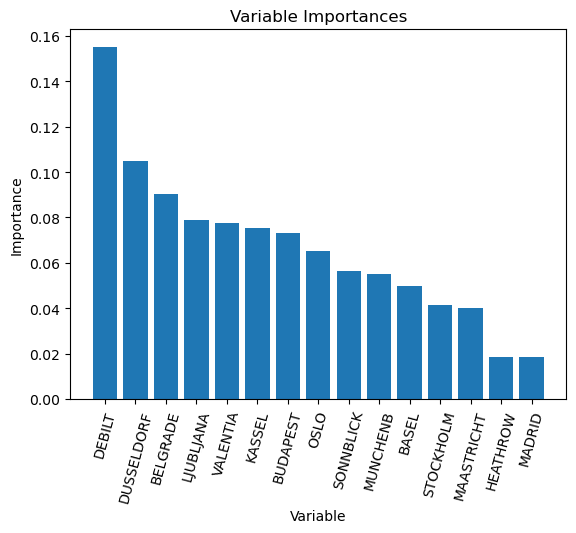

In [253]:
#plot features by importance
print(locations)
plt.bar(df_important2['Weather Station'], df_important2['Importance'], orientation = 'vertical')
plt.xticks(rotation=75, fontsize=10, ha='center')
plt.ylabel('Importance'); plt.xlabel('Variable'); plt.title('Variable Importances');
plt.show()

### Random Forest Classification with Best Hyperparameters according to Random Search

In [256]:
#print best hyperparameters and score with random search
print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best RANDOM search hyperparameters are: {'criterion': 'entropy', 'max_depth': 170, 'max_features': 16, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 460}
Best RANDOM search score is: 0.583424607520993


In [257]:
# creating a RF classifier with best hyperparameters from random search
clf4 = RandomForestClassifier(n_estimators=410, max_depth=90, max_features=16, min_samples_leaf=3, min_samples_split=8, criterion='entropy') 

In [258]:
#training model on the train dataset
clf4.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=90, max_features=16,
                       min_samples_leaf=3, min_samples_split=8,
                       n_estimators=410)

In [259]:
# performing predictions on the test dataset
y_pred = clf4.predict(X_test)
  
# using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  0.5739320920043811


[Text(0.29852027692644484, 0.96875, 'x[70] <= 14.65\nentropy = 3.115\nsamples = 1707\nvalue = [1055.0, 251.0, 162.0, 146.0, 172.0, 172.0, 164.0, 152.0\n103.0, 139.0, 114.0, 64.0, 30.0, 15.0]\nclass = 0'),
 Text(0.05866900175131348, 0.90625, 'x[70] <= 10.45\nentropy = 0.884\nsamples = 753\nvalue = [1016, 140, 34, 14, 6, 3, 1, 0, 0, 3, 0, 0, 0\n0]\nclass = 0'),
 Text(0.17859463933887915, 0.9375, 'True  '),
 Text(0.02626970227670753, 0.84375, 'x[68] <= 4.95\nentropy = 0.224\nsamples = 492\nvalue = [763, 19, 4, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]\nclass = 0'),
 Text(0.017513134851138354, 0.78125, 'x[133] <= 1.054\nentropy = 0.088\nsamples = 382\nvalue = [614, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]\nclass = 0'),
 Text(0.014010507880910683, 0.71875, 'x[63] <= 0.57\nentropy = 0.049\nsamples = 379\nvalue = [613, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]\nclass = 0'),
 Text(0.0070052539404553416, 0.65625, 'x[26] <= 6.15\nentropy = 0.391\nsamples = 16\nvalue = [24, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

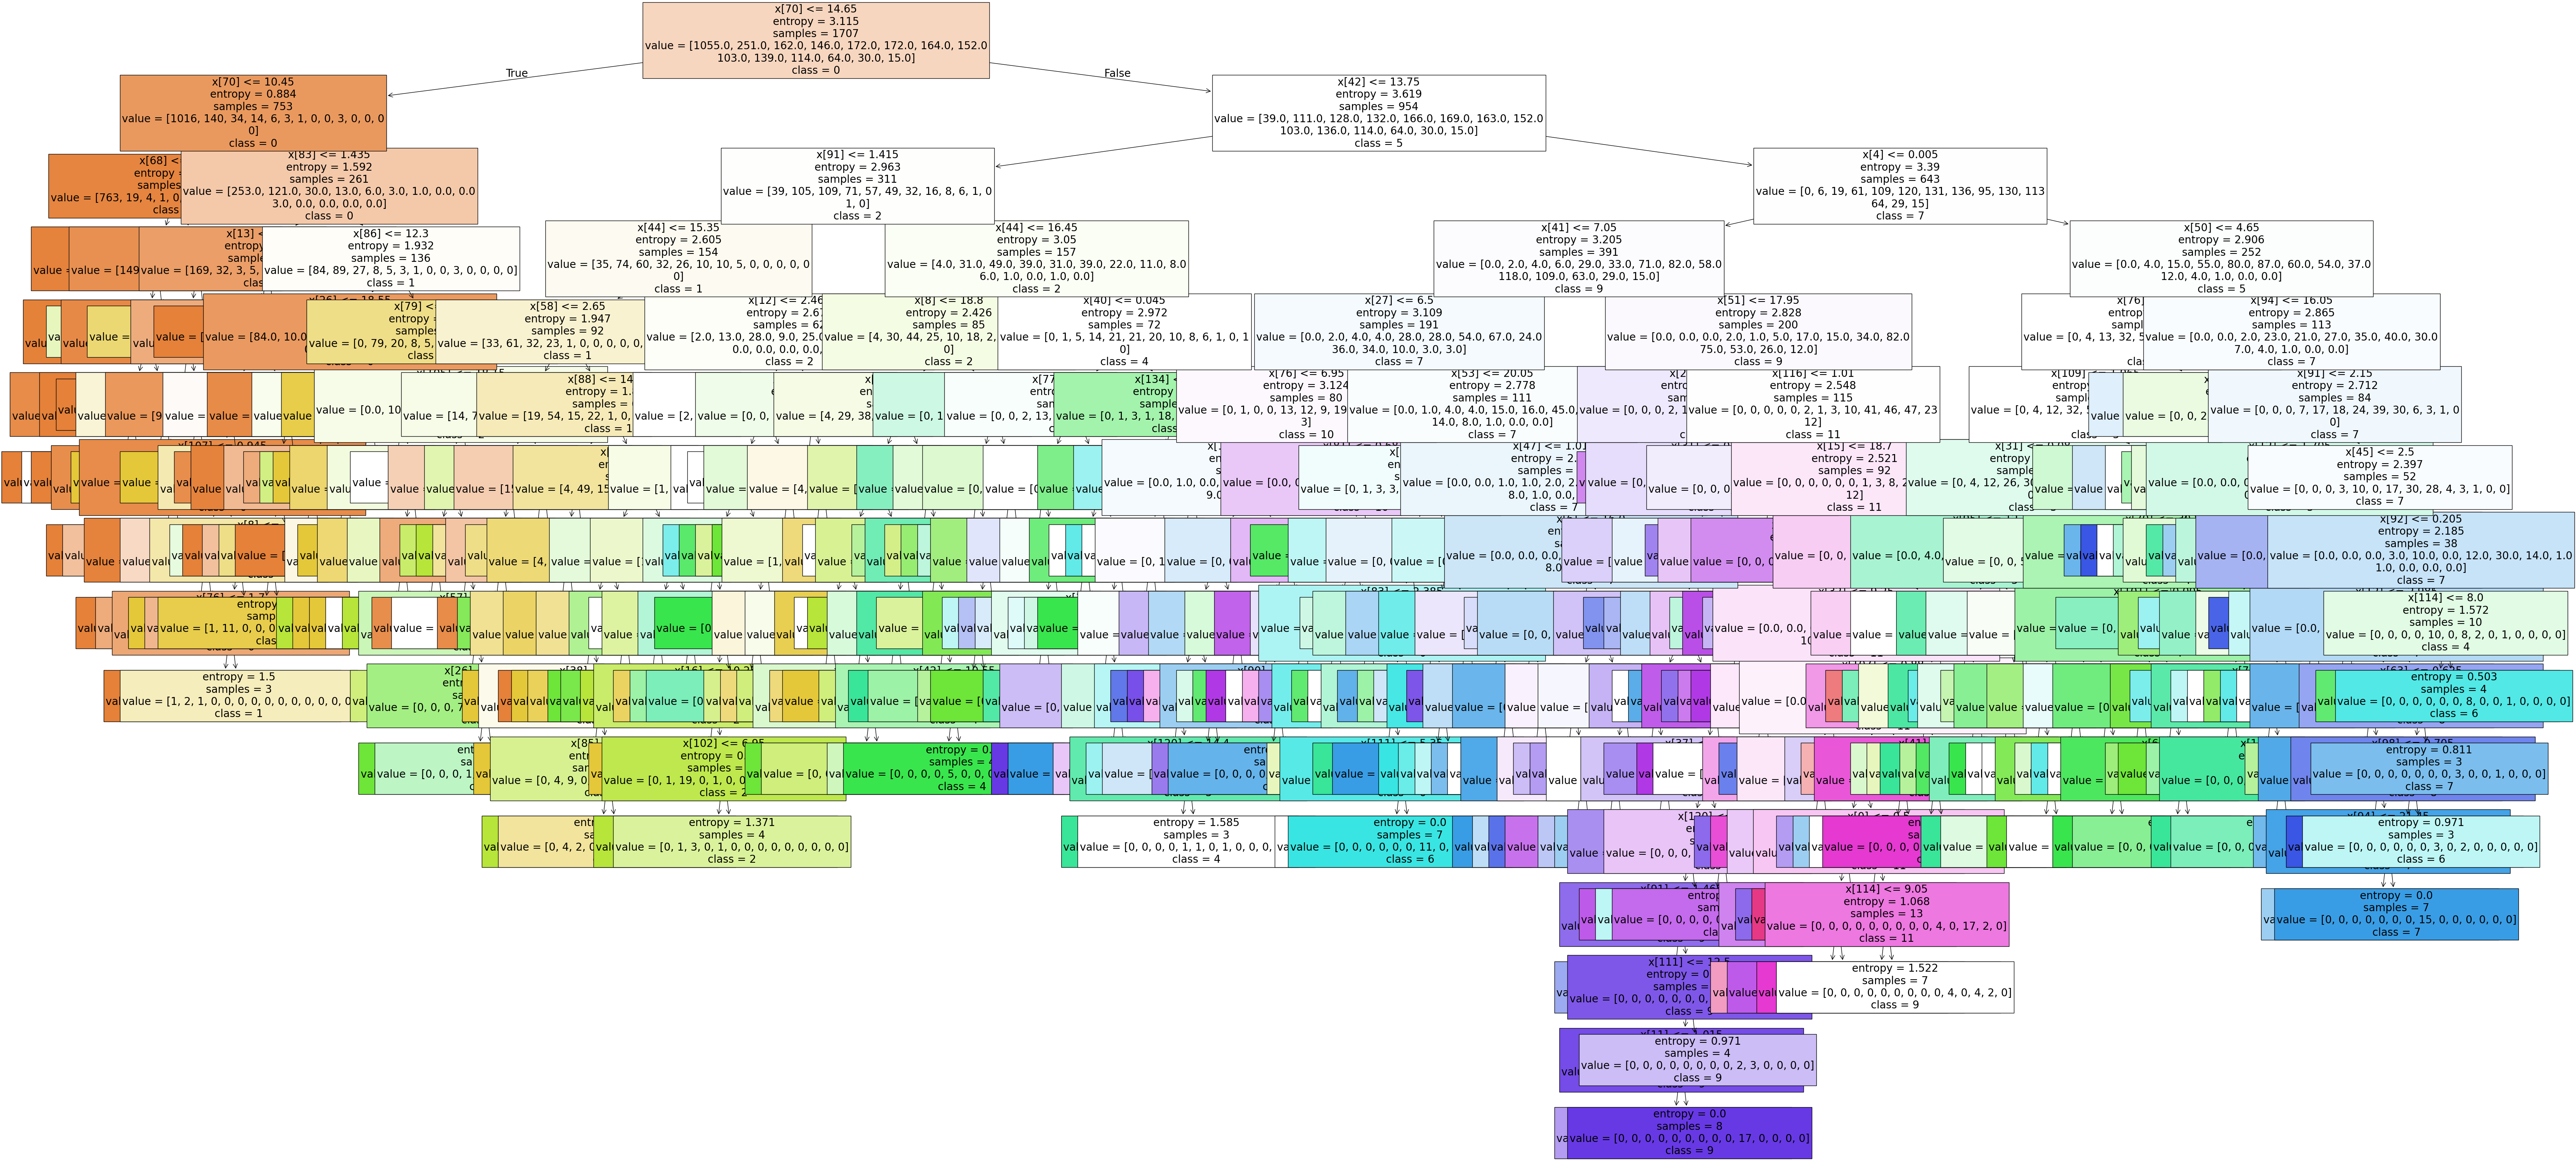

In [260]:
fig = plt.figure(figsize=(80,40))
plot_tree(clf4.estimators_[15], fontsize = 20, class_names=pleasantdays, filled=True)

#### this model is 58.1% accurate

In [262]:
fig.savefig(f"{path}/2.4_forest_random.png")

### Feature Importances with Best Hyperparameters according to Random Search

##### Weather Conditions

In [265]:
newarray3 = clf4.feature_importances_
print(clf4.feature_importances_.shape)
newarray3

(135,)


array([3.49495770e-03, 3.82862075e-03, 4.10429336e-03, 4.37625893e-03,
       1.04219888e-02, 1.27538032e-02, 3.21264582e-02, 4.82898559e-03,
       3.23513457e-02, 2.93047193e-03, 3.54695652e-03, 5.40172881e-03,
       2.83506449e-03, 3.63973212e-03, 3.43565818e-03, 8.92201562e-03,
       3.85643156e-03, 1.25715439e-02, 5.02979068e-05, 0.00000000e+00,
       0.00000000e+00, 8.63259192e-04, 4.38691059e-03, 8.69170758e-04,
       2.49910781e-02, 7.02865063e-03, 3.00059696e-02, 3.06509854e-03,
       2.91794267e-03, 5.80498556e-03, 4.44303377e-03, 1.12565097e-02,
       4.46740024e-03, 1.21701718e-02, 3.53038629e-03, 4.40423520e-02,
       2.14954614e-03, 3.07898713e-03, 6.58173135e-03, 3.67580336e-03,
       1.39086565e-02, 5.84016076e-03, 2.46765069e-02, 3.90988606e-03,
       6.05898109e-02, 3.01071441e-03, 4.27809463e-03, 4.23904697e-03,
       5.56415348e-03, 2.45845561e-03, 5.20187240e-03, 1.15838604e-02,
       3.79163434e-03, 1.60419051e-02, 1.29815137e-03, 1.92883896e-03,
      

In [266]:
#reshape feature importance array to show 15 stations, 9 features each
newarray3 = newarray3.reshape(-1,15,9)
print(newarray3.shape)
newarray

(1, 15, 9)


array([[[3.61503856e-03, 5.04398907e-03, 4.75383065e-03, 5.98755656e-03,
         7.82102490e-03, 9.14188856e-03, 2.57878194e-02, 3.75667105e-03,
         2.45353357e-02],
        [3.46885839e-03, 4.60299981e-03, 6.40216417e-03, 3.77040858e-03,
         3.98903735e-03, 4.80813661e-03, 9.45998368e-03, 5.56127507e-03,
         1.29575988e-02],
        [1.20301921e-04, 0.00000000e+00, 0.00000000e+00, 1.30480208e-03,
         3.82620451e-03, 1.15890532e-03, 3.65930410e-02, 7.07079030e-03,
         2.75684460e-02],
        [2.99259513e-03, 3.74722665e-03, 6.65121408e-03, 5.11347457e-03,
         7.13467372e-03, 5.22149452e-03, 7.42895739e-03, 4.53699375e-03,
         2.23107690e-02],
        [1.83230329e-03, 3.93804098e-03, 5.16546215e-03, 4.85797505e-03,
         8.32338320e-03, 5.20063188e-03, 1.24757672e-02, 4.47205351e-03,
         2.88692638e-02],
        [3.15078121e-03, 5.14725136e-03, 5.11558291e-03, 6.50613431e-03,
         3.02568406e-03, 5.44618325e-03, 9.69578140e-03, 4.46784777

In [267]:
#sum values for each feature
sumarray3 = np.sum(newarray3[0], axis=0)
sumarray3

array([0.05496272, 0.04935044, 0.06756004, 0.07049427, 0.10900826,
       0.12473261, 0.16941276, 0.13360166, 0.22087724])

In [268]:
#convert array into series, using the weatherconditions labels defined earlier
important3 = pd.Series(sumarray3, index = weatherconditions)
important3

SUNSHINE            0.054963
MEAN TEMP           0.049350
PRESSURE            0.067560
GLOBAL RADIATION    0.070494
HUMIDITY            0.109008
MAX TEMP            0.124733
CLOUD COVER         0.169413
PRECIPITATION       0.133602
MIN TEMP            0.220877
dtype: float64

In [269]:
#create a dataframe for plotting these features
df_important3 = pd.DataFrame({
    'Weather Condition': important3.index,
    'Importance': important3.values
})
df_important3.head

<bound method NDFrame.head of   Weather Condition  Importance
0          SUNSHINE    0.054963
1         MEAN TEMP    0.049350
2          PRESSURE    0.067560
3  GLOBAL RADIATION    0.070494
4          HUMIDITY    0.109008
5          MAX TEMP    0.124733
6       CLOUD COVER    0.169413
7     PRECIPITATION    0.133602
8          MIN TEMP    0.220877>

In [270]:
#sort values of df_important for plot clarity
df_important3 = df_important3.sort_values(by='Importance',ascending = False)

{'SUNSHINE', 'MEAN TEMP', 'PRESSURE', 'GLOBAL RADIATION', 'HUMIDITY', 'MAX TEMP', 'CLOUD COVER', 'PRECIPITATION', 'MIN TEMP'}


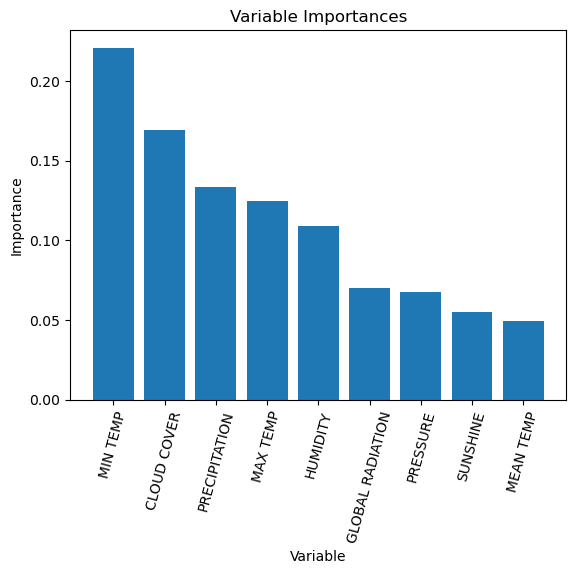

In [271]:
#plot features by importance
print(weatherconditions)
plt.bar(df_important3['Weather Condition'], df_important3['Importance'], orientation = 'vertical')
plt.xticks(rotation=75, fontsize=10, ha='center')
plt.ylabel('Importance'); plt.xlabel('Variable'); plt.title('Variable Importances');
plt.show()

##### With the hyperparameters chosen according to the Random Search optimizer, the most important features here are Minimum Temperature, Cloud Cover and Precipitation

#### Weather Stations

In [274]:
newarray4 = clf4.feature_importances_
print(clf4.feature_importances_.shape)
newarray4

(135,)


array([3.49495770e-03, 3.82862075e-03, 4.10429336e-03, 4.37625893e-03,
       1.04219888e-02, 1.27538032e-02, 3.21264582e-02, 4.82898559e-03,
       3.23513457e-02, 2.93047193e-03, 3.54695652e-03, 5.40172881e-03,
       2.83506449e-03, 3.63973212e-03, 3.43565818e-03, 8.92201562e-03,
       3.85643156e-03, 1.25715439e-02, 5.02979068e-05, 0.00000000e+00,
       0.00000000e+00, 8.63259192e-04, 4.38691059e-03, 8.69170758e-04,
       2.49910781e-02, 7.02865063e-03, 3.00059696e-02, 3.06509854e-03,
       2.91794267e-03, 5.80498556e-03, 4.44303377e-03, 1.12565097e-02,
       4.46740024e-03, 1.21701718e-02, 3.53038629e-03, 4.40423520e-02,
       2.14954614e-03, 3.07898713e-03, 6.58173135e-03, 3.67580336e-03,
       1.39086565e-02, 5.84016076e-03, 2.46765069e-02, 3.90988606e-03,
       6.05898109e-02, 3.01071441e-03, 4.27809463e-03, 4.23904697e-03,
       5.56415348e-03, 2.45845561e-03, 5.20187240e-03, 1.15838604e-02,
       3.79163434e-03, 1.60419051e-02, 1.29815137e-03, 1.92883896e-03,
      

In [275]:
#reshape feature importance array to show 15 stations, 9 features each
newarray4 = newarray4.reshape(-1,15,9)
print(newarray4.shape)

(1, 15, 9)


In [276]:
#sum values for each station
sumarray4 = np.sum(newarray4[0], axis=1)
sumarray4

array([0.10828671, 0.0471396 , 0.06819534, 0.09169788, 0.12441109,
       0.05616974, 0.016078  , 0.08705974, 0.09990679, 0.0868777 ,
       0.08210714, 0.04581178, 0.03465392, 0.03559222, 0.01601234])

In [277]:
#convert array into series, using locations labels defined earlier
important4 = pd.Series(sumarray4, index = locations)
important4

BELGRADE      0.108287
MUNCHENB      0.047140
VALENTIA      0.068195
OSLO          0.091698
KASSEL        0.124411
SONNBLICK     0.056170
HEATHROW      0.016078
DUSSELDORF    0.087060
LJUBLJANA     0.099907
DEBILT        0.086878
BUDAPEST      0.082107
BASEL         0.045812
MAASTRICHT    0.034654
STOCKHOLM     0.035592
MADRID        0.016012
dtype: float64

In [278]:
#create a dataframe for plotting these features
df_important4 = pd.DataFrame({
    'Weather Station': important4.index,
    'Importance': important4.values
})
df_important4.head

<bound method NDFrame.head of    Weather Station  Importance
0         BELGRADE    0.108287
1         MUNCHENB    0.047140
2         VALENTIA    0.068195
3             OSLO    0.091698
4           KASSEL    0.124411
5        SONNBLICK    0.056170
6         HEATHROW    0.016078
7       DUSSELDORF    0.087060
8        LJUBLJANA    0.099907
9           DEBILT    0.086878
10        BUDAPEST    0.082107
11           BASEL    0.045812
12      MAASTRICHT    0.034654
13       STOCKHOLM    0.035592
14          MADRID    0.016012>

In [279]:
#sort values in descending order for chart clarity
df_important4 = df_important4.sort_values(by='Importance',ascending = False)

{'BELGRADE', 'MUNCHENB', 'VALENTIA', 'OSLO', 'KASSEL', 'SONNBLICK', 'HEATHROW', 'DUSSELDORF', 'LJUBLJANA', 'DEBILT', 'BUDAPEST', 'BASEL', 'MAASTRICHT', 'STOCKHOLM', 'MADRID'}


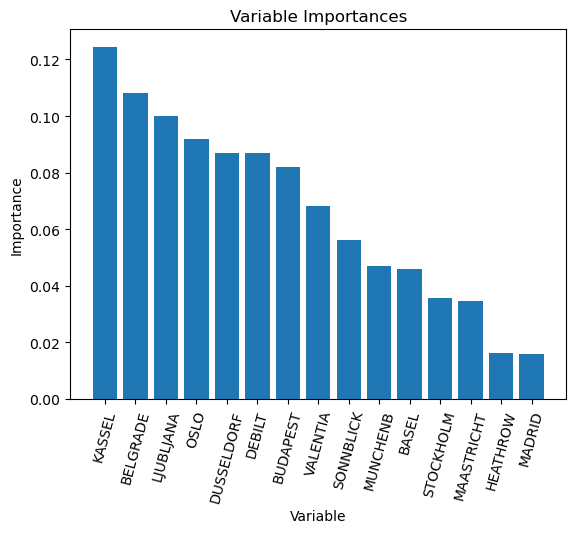

In [280]:
#plot features by importance
print(locations)
plt.bar(df_important4['Weather Station'], df_important4['Importance'], orientation = 'vertical')
plt.xticks(rotation=75, fontsize=10, ha='center')
plt.ylabel('Importance'); plt.xlabel('Variable'); plt.title('Variable Importances');
plt.show()

##### With the hyperparameters chosen by the Random Search optimizer, the data from Oslo, Belgrade and Düsseldorf are the most important features for the classifier.